In [1]:
import os
import operator
from difflib import SequenceMatcher
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import (
    AnyMessage, HumanMessage, SystemMessage, ToolMessage,
    RemoveMessage,
)

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, REMOVE_ALL_MESSAGES
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

from ddgs import DDGS

load_dotenv()

True

In [2]:
# ======================================================================
# 1. MODELLE
# ======================================================================

llm_supervisor = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
llm_researcher = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
llm_analyst    = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
llm_writer     = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
llm_critic     = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)

# Andere günstige/schlanke Modelle:
# llm_supervisor = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)
# llm_researcher = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.1)
# llm_analyst    = ChatOllama(model="qwen3.5:9b", temperature=0.2)
# llm_writer     = ChatOllama(model="llama3.1:8b", temperature=0.7)
# llm_critic     = ChatOllama(model="qwen2.5:7b", temperature=0.1)

In [3]:
# ======================================================================
# 2. TOOL
# ======================================================================

@tool
def web_suche(query: str) -> str:
    """Sucht im Web nach aktuellen Informationen zu einer Anfrage.
    Nutze dies, wenn du Informationen brauchst, die du nicht sicher weisst
    oder die aktuell/2026 sein koennte.

    Args:
        query: Die Suchanfrage, z.B. "Schwingfest 2026 Termine Schweiz"
    """
    with DDGS() as ddgs:
        ergebnisse = list(ddgs.text(query, max_results=4))
    if not ergebnisse:
        return "Keine Ergebnisse gefunden."
    return "\n\n".join(
        f"Titel: {r['title']}\nURL: {r['href']}\nAuszug: {r['body']}"
        for r in ergebnisse
    )

tools = [web_suche]
llm_researcher_mit_tools = llm_researcher.bind_tools(tools)
node_tools = ToolNode(tools)

In [4]:
# ======================================================================
# 3. STRUKTURIERTER OUTPUT
# ======================================================================

class BranchEntscheidung(BaseModel):
    next: Literal["researcher", "writer", "eskalation"] = Field(
        description="researcher wenn Fakten/Daten/Zahlen/Quellen fehlen, "
        "writer wenn nur Formulierung/Struktur/Laenge betroffen ist, "
        "eskalation wenn keiner der beiden sinnvoll ist."
    )

llm_branch_structured = llm_supervisor.with_structured_output(BranchEntscheidung)

BRANCH_SYSTEM = """Du entscheidest NUR eine Sache: ob nach negativem Feedback
der researcher oder der writer erneut arbeiten soll.

Regeln:
1. Waehle "researcher", wenn dem Bericht faktische Informationen, Daten,
   Zahlen oder Quellen fehlen.
2. Waehle "writer", wenn die vorhandenen Informationen ausreichen, aber
   Formulierung, Struktur oder Laenge mangelhaft sind.
3. Waehle "eskalation" nur, wenn das Feedback keinem der beiden Faelle
   eindeutig zugeordnet werden kann.
Antworte NUR mit dem Feld next."""


class CriticBewertung(BaseModel):
    ausreichend: bool = Field(
        description="True wenn ALLE Kriterien erfuellt sind: "
        "(1) mind. 3 konkrete Zahlen/Statistiken, "
        "(2) max. 300 Woerter, "
        "(3) mind. 2 verschiedene Perspektiven/Aspekte abgedeckt."
    )
    grund: Literal["daten", "formulierung", "keine"] = Field(
        description="Bei ausreichend=False: 'daten' wenn Fakten/Zahlen/Quellen "
        "fehlen, 'formulierung' wenn nur Sprache/Struktur/Laenge betroffen ist. "
        "Bei ausreichend=True: 'keine'."
    )
    feedback: str = Field(
        description="Falls ausreichend=False: konkretes Feedback was fehlt oder "
        "verbessert werden muss. Falls ausreichend=True: leerer String."
    )

llm_critic_structured = llm_critic.with_structured_output(CriticBewertung)

In [5]:
# ======================================================================
# 4. DER STATE
# ======================================================================

MAX_RETRIES = 2      # harte Obergrenze pro Worker
MAX_ZYKLEN = 8       # harte globale Obergrenze ueber alle Schritte

class SupervisorState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    thema: str
    next: str
    instruction: str
    #recherche: str
    recherche: Annotated[list[str], operator.add]
    analyse: str
    bericht: str
    verlauf: Annotated[list[str], operator.add]
    critic_ausreichend: bool
    critic_feedback: str
    critic_grund: str
    freigabe_feedback: str
    researcher_retries: int
    writer_retries: int
    last_critic_feedback: str
    last_freigabe_feedback: str
    zyklus_count: int
    log: Annotated[list[dict], operator.add] # Reines Analyse-Log, wird nie an LLMs uebergeben

In [6]:
# ======================================================================
# 5. NODES
# ======================================================================

def _feedback_aehnlich(a: str, b: str) -> bool:
    """Erkennt, ob sich Feedback zwischen zwei Runden kaum
    veraendert hat -> starkes Signal fuer eine Endlosschleife trotz
    Ueberarbeitung."""
    if not a or not b:
        return False
    return SequenceMatcher(None, a, b).ratio() > 0.85


def _entscheide_branch(state: SupervisorState, quelle: str) -> tuple[str, str, dict]:
    """Gekapselte Funktion fuer die zwei einzigen echten
    inhaltlichen Entscheidungen des Supervisors (Regel 5 und 8).
    Gibt (next_worker, instruction, extra_state_updates) zurueck."""

    zyklus_count = state.get("zyklus_count", 0)
    
    aktuelles_feedback = (
        state.get("critic_feedback", "") if quelle == "critic"
        else state.get("freigabe_feedback", "")
    )
    letztes_feedback = (
        state.get("last_critic_feedback", "") if quelle == "critic"
        else state.get("last_freigabe_feedback", "")
    )
    researcher_retries = state.get("researcher_retries", 0)
    writer_retries = state.get("writer_retries", 0)
    researcher_verfuegbar = researcher_retries < MAX_RETRIES
    writer_verfuegbar = writer_retries < MAX_RETRIES

    extra: dict = {
        "last_critic_feedback": state.get("last_critic_feedback", ""),
        "last_freigabe_feedback": state.get("last_freigabe_feedback", ""),
    }
    if quelle == "critic":
        extra["last_critic_feedback"] = aktuelles_feedback
    else:
        extra["last_freigabe_feedback"] = aktuelles_feedback

    if zyklus_count >= MAX_ZYKLEN:
        print(f"[Supervisor] Retry-Runden-Limit ({MAX_ZYKLEN}) erreicht "
              f"-> Eskalation.")
        return "FINISH", "Eskalation: maximale Anzahl an Ueberarbeitungsrunden erreicht.", extra
    
    # Ähnlichkeits-Check -> Eskalation statt weiterer Iteration
    if _feedback_aehnlich(aktuelles_feedback, letztes_feedback):
        print(f"[Supervisor] Feedback von '{quelle}' aehnelt dem "
              f"vorherigen -> Eskalation statt weiterer Iteration.")
        return "FINISH", f"Eskalation: wiederholtes Feedback von {quelle} ohne erkennbare Verbesserung.", extra

    # harte Retry-Limits im Code, unabhaengig von jeder LLM-Entscheidung
    if not researcher_verfuegbar and not writer_verfuegbar:
        print("[Supervisor] Retry-Limits fuer researcher UND writer "
              "erschoepft -> Eskalation.")
        return "FINISH", "Eskalation: Retry-Limits erschoepft.", extra

    if quelle == "critic" and state.get("critic_grund") in ("daten", "formulierung"):
        # direktes Mapping aus dem strukturierten Critic-Feld,
        # kein zusaetzlicher LLM-Call noetig (zuverlaessiger als Freitext-Interpretation)
        next_worker = "researcher" if state["critic_grund"] == "daten" else "writer"
    else:
        # freigabe liefert Freitext eines Menschen -> das kann nur ein LLM klassifizieren.
        # strukturierte, vorberechnete Kennzahlen statt Rohtext-Historie
        kontext = (
            f"Feedback von {quelle}: {aktuelles_feedback}\n\n"
            f"Verbleibende researcher-Versuche: {max(0, MAX_RETRIES - researcher_retries)}\n"
            f"Verbleibende writer-Versuche: {max(0, MAX_RETRIES - writer_retries)}\n"
        )
        entscheidung = llm_branch_structured.invoke([
            SystemMessage(content=BRANCH_SYSTEM),
            HumanMessage(content=kontext),
        ])
        next_worker = entscheidung.next

    # Retry-Limit im Code erzwingen, auch wenn grund/LLM anders entscheidet
    if next_worker == "researcher" and not researcher_verfuegbar:
        next_worker = "writer" if writer_verfuegbar else "FINISH"
    if next_worker == "writer" and not writer_verfuegbar:
        next_worker = "researcher" if researcher_verfuegbar else "FINISH"
    if next_worker == "eskalation":
        next_worker = "FINISH"

    if next_worker == "researcher":
        extra["researcher_retries"] = researcher_retries + 1
    elif next_worker == "writer":
        extra["writer_retries"] = writer_retries + 1

    if next_worker in ("researcher", "writer"):
        extra["zyklus_count"] = zyklus_count + 1  # nur bei echtem Retry hochzaehlen

    # Logging des Retry-Grundes fuer besseres Debugging von Loops
    print(f"[Supervisor] Branch-Entscheidung wegen {quelle}-Feedback "
          f"(bisher researcher={researcher_retries}x, writer={writer_retries}x) "
          f"-> {next_worker}")

    instruction = f"Ueberarbeite basierend auf Feedback von {quelle}: {aktuelles_feedback}"
    return next_worker, instruction, extra


def node_supervisor(state: SupervisorState) -> dict:
    verlauf = state.get("verlauf", [])
    letzter = verlauf[-1] if verlauf else None

    # deterministisches Routing in Code statt LLM-Aufruf fuer jede
    # feste Regel. Das LLM wird nur bei den zwei echten inhaltlichen
    # Verzweigungen über _entscheide_branch() befragt.
    extra_updates: dict = {}
    if letzter is None:
        next_worker, instruction = "researcher", "Recherchiere gruendlich zum Thema."
    elif letzter == "researcher":
        next_worker, instruction = "analyst", "Analysiere die Recherche."
    elif letzter == "analyst":
        next_worker, instruction = "writer", "Schreibe den Bericht basierend auf der Analyse."
    elif letzter == "writer":
        next_worker, instruction = "critic", "Bewerte den Bericht."
    elif letzter == "critic":
        if state.get("critic_ausreichend"):
            next_worker, instruction = "freigabe", "Hole die menschliche Freigabe ein."
        else:
            next_worker, instruction, extra_updates = _entscheide_branch(state, quelle="critic")
    elif letzter == "freigabe":
        fb = state.get("freigabe_feedback", "")
        if fb.strip().lower() == "ok":
            next_worker, instruction = "FINISH", "Bericht freigegeben."
        else:
            next_worker, instruction, extra_updates = _entscheide_branch(state, quelle="freigabe")
    else:
        next_worker, instruction = "FINISH", "Unbekannter Zustand, Abbruch."

    print(f"\n[Supervisor] -> {next_worker}: {instruction[:80]}...")
    return {"next": next_worker, "instruction": instruction, **extra_updates}


def node_researcher(state: SupervisorState) -> dict:
    instruction = state.get("instruction") or "Recherchiere das Thema."

    # Feedback-Grundlage fuer das Log erfassen, bevor es weiter unten geleert wird
    mensch_fb = state.get("freigabe_feedback", "")
    critic_fb = state.get("critic_feedback", "")
    basierend_auf_feedback = None
    if mensch_fb and mensch_fb.strip().lower() != "ok":
        basierend_auf_feedback = f"freigabe: {mensch_fb}"
    elif critic_fb:
        basierend_auf_feedback = f"critic: {critic_fb}"
    
    #system = SystemMessage(content=(
    #    "Du bist ein gruendlicher Researcher. Nutze das web_suche-Tool, um "
    #    "Informationen zum Thema zu sammeln. Wenn du genug Informationen hast, "
    #    "fasse sie in Fliesstext zusammen, OHNE weiteres Tool aufzurufen."
    #))
    system = SystemMessage(content=(
        "Du bist ein gruendlicher Researcher, KEIN Autor und KEIN Zusammenfasser. "
        "Nutze das web_suche-Tool so oft wie noetig, um Informationen zum Thema zu "
        "sammeln. Sobald du genug Suchergebnisse hast, rufe KEIN weiteres Tool mehr "
        "auf. Deine abschliessende Textantwort wird NICHT weiterverwendet - schreibe "
        "dort nur kurz, dass die Recherche abgeschlossen ist (z.B. 'Ausreichend "
        "Informationen gefunden.'). Fasse die Suchergebnisse NICHT inhaltlich "
        "zusammen und formuliere sie nicht um - das uebernimmt ein spaeterer Schritt.\n\n"
        "WICHTIG: Es gibt niemanden, der deine Rueckfragen beantworten kann. Stelle "
        "daher NIEMALS Rueckfragen und bitte NIEMALS um zusaetzlichen Kontext oder "
        "den bisherigen Bericht. Leite aus dem gegebenen Thema und der Aufgabe "
        "selbststaendig ab, wonach gesucht werden soll, und fuehre die Suche direkt "
        "aus. Triff bei Unklarheiten eine sinnvolle eigene Annahme statt nachzufragen."
    ))
    neue_anweisung = HumanMessage(content=(
        f"Thema: {state['thema']}\n"
        f"Aufgabe: {instruction}"
    ))
    # neue Anweisung ans ENDE der Message-Historie stellen statt davor,
    # damit das Modell nicht durch eine "aeltere" Anweisung nach der neuen verwirrt wird.
    prompt_messages = [system] + state["messages"] + [neue_anweisung]
    response = llm_researcher_mit_tools.invoke(prompt_messages)
    update: dict = {"messages": [response]}
    
    if not getattr(response, "tool_calls", None):
        # Rohe Suchresultate (ToolMessages) dieser Runde sammeln,
        # statt der LLM-eigenen Zusammenfassung (response.content)
        neue_rohdaten = "\n\n".join(
            m.content for m in state["messages"] + [response]
            if isinstance(m, ToolMessage) and isinstance(m.content, str)
        )
        if not neue_rohdaten:
            # Fallback: Modell hat ohne Toolaufruf direkt geantwortet
            print("\n[Researcher] WARNUNG: keine Tool-Ergebnisse gefunden, "
                  "nutze response.content als Fallback.")
            neue_rohdaten = response.content

        print(f"\n[Researcher] Fertig ({len(neue_rohdaten)} Zeichen neue Rohdaten)")
        
        # recherche ist Annotated[list[str], operator.add] -> neuer Chunk wird
        # automatisch an bisherige Rohdaten angehaengt, kein manuelles Verketten noetig
        update["recherche"] = [neue_rohdaten]
        update["verlauf"] = ["researcher"]

        # verbrauchtes/stale Feedback zuruecksetzen, damit der naechste
        # Schritt (analyst/writer) nicht auf veraltetem Critic-/Freigabe-Feedback basiert
        update["critic_feedback"] = ""
        update["freigabe_feedback"] = ""
        # Message-Kanal nach abgeschlossener Recherche-Runde leeren,
        # damit er ueber mehrere Researcher-Zyklen hinweg nicht unbegrenzt waechst
        update["messages"] = [response, RemoveMessage(id=REMOVE_ALL_MESSAGES)]
        update["log"] = [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "researcher",
            "recherche": neue_rohdaten,
            "basierend_auf_feedback": basierend_auf_feedback,
        }]
    return update


def node_analyst(state: SupervisorState) -> dict:
    instruction = state.get("instruction") or "Analysiere die Recherche."
    #rohdaten = "\n\n".join(
    #    m.content for m in state["messages"]
    #    if isinstance(m, ToolMessage) and isinstance(m.content, str)
    #) or state.get("recherche", "")
    rohdaten = "\n\n".join(state.get("recherche", []))   # Liste -> String
    response = llm_analyst.invoke(
        f"Thema: {state['thema']}\n"
        f"Aufgabe: {instruction}\n\n"
        f"--- ROHDATEN ---\n{rohdaten}\n--- ENDE ---\n\n"
        f"Erstelle eine strukturierte Analyse (3-5 Erkenntnisse, "
        f"konkrete Fakten, KEINE Rueckfragen)."
    )
    print(f"\n[Analyst] Fertig ({len(response.content)} Zeichen)")
    return {
        "analyse": response.content,
        "verlauf": ["analyst"],
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "analyst",
            "analyse": response.content,
        }],
    }
    #return {"analyse": response.content, "verlauf": ["analyst"]}


def node_writer(state: SupervisorState) -> dict:
    instruction = state.get("instruction") or "Schreibe den Bericht."
    feedback_teil = ""
    mensch_fb = state.get("freigabe_feedback", "")
    critic_fb = state.get("critic_feedback", "")
    if mensch_fb and mensch_fb.strip().lower() != "ok":
        feedback_teil = (
            f"\nFeedback des Menschen zum vorherigen Bericht:\n{mensch_fb}\n"
            f"Bitte beruecksichtige dieses Feedback bei der Ueberarbeitung.\n"
        )
    elif critic_fb:
        feedback_teil = (
            f"\nFeedback des Critics zum vorherigen Bericht:\n{critic_fb}\n"
            f"Bitte beruecksichtige dieses Feedback bei der Ueberarbeitung.\n"
        )
    response = llm_writer.invoke(
        f"Thema: {state['thema']}\n"
        f"Aufgabe: {instruction}\n"
        f"{feedback_teil}\n"
        f"Analyse:\n{state.get('analyse', '')}\n\n"
        f"Schreibe einen kompakten Kurzbericht (max. 300 Woerter) mit Zwischentiteln."
    )
    print(f"\n[Writer] Fertig ({len(response.content)} Zeichen)")
    return {
        "bericht": response.content,
        "verlauf": ["writer"],
        # verbrauchtes Feedback zuruecksetzen, damit es nicht in einer
        # spaeteren Runde faelschlich erneut als "aktuell" interpretiert wird
        "critic_feedback": "",
        "freigabe_feedback": "",
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "writer",
            "bericht": response.content,
            "basierend_auf_feedback": feedback_teil.strip() or None,
        }],
    }


def node_critic(state: SupervisorState) -> dict:
    prompt = (
        f"Bewerte STRENG den folgenden Bericht zum Thema '{state['thema']}'.\n\n"
        f"--- BERICHT ---\n{state.get('bericht', '')}\n--- ENDE BERICHT ---\n\n"
        f"Kriterien (ALLE muessen erfuellt sein fuer ausreichend=True):\n"
        f"1. Mind. 3 konkrete Zahlen oder Statistiken enthalten\n"
        f"2. Max. 300 Woerter\n"
        f"3. Mind. 2 verschiedene Perspektiven oder Aspekte des Themas abgedeckt\n\n"
        f"Falls ausreichend=False: konkretes Feedback was genau fehlt, und "
        f"klassifiziere den Grund (grund='daten' oder grund='formulierung'). "
        f"Falls ausreichend=True: feedback leer lassen, grund='keine'."
    )
    bewertung = llm_critic_structured.invoke(prompt)
    print(f"\n[Critic] ausreichend={bewertung.ausreichend}, grund={bewertung.grund}"
          + (f": {bewertung.feedback[:80]}..." if bewertung.feedback else ""))
    return {
        "critic_ausreichend": bewertung.ausreichend,
        "critic_feedback": bewertung.feedback,
        "critic_grund": bewertung.grund,
        "verlauf": ["critic"],
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "critic",
            "ausreichend": bewertung.ausreichend,
            "grund": bewertung.grund,
            "feedback": bewertung.feedback,
        }],
        }


def node_freigabe(state: SupervisorState) -> dict:
    """Pausiert den Graphen - wird nur erreicht wenn Critic ausreichend=True."""
    print("\n" + "="*60)
    print("BERICHT ZUR FREIGABE (Critic: ausreichend=True):")
    print("="*60)
    print(state.get("bericht", ""))
    print("="*60)

    mensch_input = interrupt(
        "Bericht freigeben? Eingabe:\n"
        "  'ok'       -> freigeben (FINISH)\n"
        "  <Feedback> -> Writer ueberarbeitet mit diesem Feedback"
    )
    print(f"\n[Freigabe] Mensch-Input: '{mensch_input}'")
    return {
        "freigabe_feedback": mensch_input,
        "verlauf": ["freigabe"],
        "log": [{
            "schritt": len(state.get("verlauf", [])) + 1,
            "knoten": "freigabe",
            "feedback": mensch_input,
        }],
    }
    #return {"freigabe_feedback": mensch_input, "verlauf": ["freigabe"]}

In [7]:
# ======================================================================
# 6. ROUTING
# ======================================================================

def route_supervisor(state: SupervisorState) -> Literal[
    "researcher", "analyst", "writer", "critic", "freigabe", END
]:
    next_worker = state.get("next", "FINISH")
    if next_worker == "FINISH":
        return END
    return next_worker


def route_researcher(state: SupervisorState) -> Literal["tools", "supervisor"]:
    if not state["messages"]:          # leere Liste nach RemoveMessage(ALL) abfangen
        return "supervisor"
    letzte_message = state["messages"][-1]
    if hasattr(letzte_message, "tool_calls") and letzte_message.tool_calls:
        return "tools"
    return "supervisor"

In [8]:
# ======================================================================
# 7. DER GRAPH MIT MEMORYSAVER
# ======================================================================

memory = MemorySaver()

graph_builder = StateGraph(SupervisorState)

graph_builder.add_node("supervisor", node_supervisor)
graph_builder.add_node("researcher", node_researcher)
graph_builder.add_node("tools", node_tools)
graph_builder.add_node("analyst", node_analyst)
graph_builder.add_node("writer", node_writer)
graph_builder.add_node("critic", node_critic)
graph_builder.add_node("freigabe", node_freigabe)

graph_builder.add_edge(START, "supervisor")
graph_builder.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {
        "researcher": "researcher",
        "analyst": "analyst",
        "writer": "writer",
        "critic": "critic",
        "freigabe": "freigabe",
        END: END,
    },
)
graph_builder.add_conditional_edges(
    "researcher",
    route_researcher,
    {"tools": "tools", "supervisor": "supervisor"},
)
graph_builder.add_edge("tools", "researcher")
graph_builder.add_edge("analyst", "supervisor")
graph_builder.add_edge("writer", "supervisor")
graph_builder.add_edge("critic", "supervisor")
graph_builder.add_edge("freigabe", "supervisor")

graph = graph_builder.compile(checkpointer=memory)

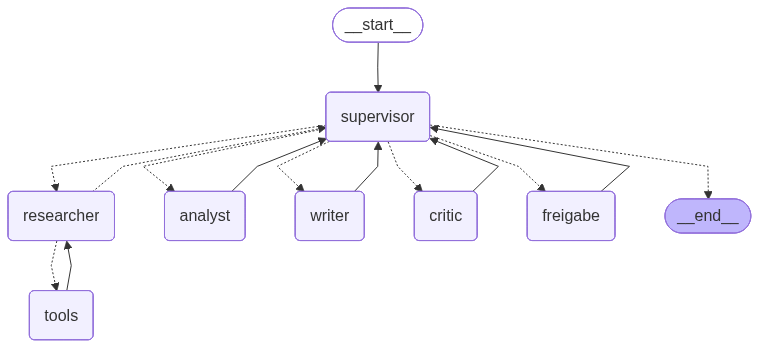

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
import uuid

#thema = 'KI-Trends im Marketing 2026'
#thema = 'Organisation von Schwingfesten 2026'
thema = "KI-Trends im Marketing 2026"

# recursion_limit bewusst erhoehen, da unser eigener
# zyklus_count-Zaehler (MAX_ZYKLEN) jetzt die eigentliche, sauber
# eskalierende Notbremse ist statt eines harten LangGraph-Abbruchs.
# Und Thread-ID setzen, damit diese Notebook-Zelle immer wieder ausgeführt werden kann.
config = {"configurable": {"thread_id": str(uuid.uuid4())}, "recursion_limit": 50}

ergebnis = graph.invoke(
    {
        "messages": [],
        "thema": thema,
        "next": "",
        "instruction": "",
        "recherche": [],
        "analyse": "",
        "bericht": "",
        "verlauf": [],
        "critic_ausreichend": False,
        "critic_feedback": "",
        "critic_grund": "keine",
        "freigabe_feedback": "",
        "researcher_retries": 0,
        "writer_retries": 0,
        "last_critic_feedback": "",
        "last_freigabe_feedback": "",
        "zyklus_count": 0,
        "log": [],
    },
    config=config,
)

# Schleife für Human-in-the-Loop
while "__interrupt__" in ergebnis:
    mensch_input = input("\nEingabe (ok / Feedback): ").strip() or "ok"
    ergebnis = graph.invoke(Command(resume=mensch_input), config=config)

print("\n" + "="*60)
print(f"Verlauf: {' -> '.join(ergebnis['verlauf'])}")
print("FINALER BERICHT")
print("="*60)
print(ergebnis["bericht"])


[Supervisor] -> researcher: Recherchiere gruendlich zum Thema....

[Researcher] Fertig (4232 Zeichen neue Rohdaten)

[Supervisor] -> analyst: Analysiere die Recherche....

[Analyst] Fertig (1799 Zeichen)

[Supervisor] -> writer: Schreibe den Bericht basierend auf der Analyse....

[Writer] Fertig (1934 Zeichen)

[Supervisor] -> critic: Bewerte den Bericht....

[Critic] ausreichend=False, grund=daten: Der Bericht enthält keine konkreten Zahlen oder Statistiken, die die Aussagen un...
[Supervisor] Branch-Entscheidung wegen critic-Feedback (bisher researcher=0x, writer=0x) -> researcher

[Supervisor] -> researcher: Ueberarbeite basierend auf Feedback von critic: Der Bericht enthält keine konkre...

[Researcher] Fertig (5955 Zeichen neue Rohdaten)

[Supervisor] -> analyst: Analysiere die Recherche....

[Analyst] Fertig (1843 Zeichen)

[Supervisor] -> writer: Schreibe den Bericht basierend auf der Analyse....

[Writer] Fertig (1859 Zeichen)

[Supervisor] -> critic: Bewerte den Bericht....




Eingabe (ok / Feedback):  Der Bericht soll mit 2-3 Zahlen erweitert werden.



BERICHT ZUR FREIGABE (Critic: ausreichend=True):
# KI-Trends im Marketing 2026

## Integration von KI in Marketingstrategien
Im Jahr 2026 hat sich Künstliche Intelligenz (KI) als unverzichtbare Infrastruktur im Marketing etabliert. Unternehmen, die KI, Daten und Governance nicht synchron integrieren, laufen Gefahr, an Geschwindigkeit und Vertrauen zu verlieren. Dies führt zu einer grundlegenden Transformation von Prozessen, Rollen und Entscheidungslogiken (Mind-Force, 2026).

## Generative KI und datengetriebene Personalisierung
Generative KI ist ein Schlüsselfaktor für die Effizienzsteigerung in der Inhaltserstellung und Kampagnenentwicklung. Gleichzeitig ermöglicht datengetriebene Personalisierung eine präzisere Ansprache der Kunden. 91 % der Marketer setzen KI aktiv in ihren Arbeitsabläufen ein, was die Standardisierung dieser Technologien im Marketing unterstreicht (Moin.ai, 2026; SaaSultra, 2026).

## Frühe Nutzeransprache durch Demand-Gen-Kampagnen
Die Ansprache potenzieller Kun


Eingabe (ok / Feedback):  Die Zahlen sollen nicht auf ganze Zahlen, sondern auf 1 Stelle nach dem Komma gerundet werden. Dezimalzahlen mit Punkt darstellen (z.b. 47.5 statt 47,5).



BERICHT ZUR FREIGABE (Critic: ausreichend=True):
### KI-Trends im Marketing 2026

#### Integration von KI in Marketingstrategien
Im Jahr 2026 hat sich Künstliche Intelligenz (KI) als unverzichtbare Infrastruktur im Marketing etabliert. Unternehmen, die KI, Daten und Governance nicht synergistisch betrachten, laufen Gefahr, an Geschwindigkeit und Vertrauen zu verlieren. Diese integrative Herangehensweise ist entscheidend für die Zukunftsfähigkeit im Marketing (Mind-Force, KG Media).

#### Personalisierung und Datengetriebenheit
Die datengetriebene Personalisierung ist ein zentraler Trend. Laut aktuellen Studien setzen 91 % der Marketer KI aktiv ein, während 93 % der Chief Marketing Officers (CMOs) einen messbaren ROI durch generative KI berichten (SaaSultra, VoxBooster). Dies unterstreicht die wachsende Bedeutung maßgeschneiderter Marketingansätze, die auf die individuellen Bedürfnisse der Verbraucher zugeschnitten sind.

#### Optimierung der Suchstrategien
Die Optimierung von Inhalten


Eingabe (ok / Feedback):  ok



BERICHT ZUR FREIGABE (Critic: ausreichend=True):
### KI-Trends im Marketing 2026

1. **Integration von KI in Marketingstrategien**  
Künstliche Intelligenz wird 2026 als fundamentale Infrastruktur im Marketing anerkannt, die Prozesse, Rollen und Entscheidungslogiken grundlegend transformiert. Unternehmen, die KI, Daten und Governance nicht synergetisch betrachten, riskieren, an Geschwindigkeit und Vertrauen zu verlieren (Mind-Force, KG Media).

2. **Personalisierung und datengetriebene Ansätze**  
Die datengetriebene Personalisierung zeigt sich als zentraler Trend. 91.0 % der Marketer setzen KI aktiv in ihren Arbeitsabläufen ein, während 93.0 % der CMOs von einem messbaren ROI durch generative KI berichten (SaaSultra, VoxBooster). Dies verdeutlicht, dass Unternehmen zunehmend maßgeschneiderte Marketingstrategien verfolgen, die auf den individuellen Bedürfnissen der Verbraucher basieren.

3. **Veränderung der Suchstrategien**  
Marken optimieren ihre Inhalte verstärkt für die KI-Suche.

In [11]:
log = ergebnis["log"]
for eintrag in log:
    if eintrag['knoten'] == 'researcher':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('recherche:', eintrag['recherche'], '\n')
        print('basierend_auf_feedback:', eintrag['basierend_auf_feedback'], '\n')

[1] knoten: researcher 

recherche: Titel: AI-Marketing-Trends 2026: Die wichtigsten Entwicklungen für...
URL: https://www.moin.ai/chatbot-lexikon/ai-marketing-trends-2026
Auszug: Wir untersuchen Trends und Prognosen im KI-Marketing und zeigen, welche Trends 2026 besonders wichtig sind und welche Rolle Verbraucherdaten spielen.

Titel: Die wichtigsten Marketing-Statistiken und Trends zu KI, AEO & Social...
URL: https://blog.hubspot.de/marketing/state-of-marketing-report
Auszug: Top-Trends im digitalen Marketing 2026. 1. Marken optimieren ihre Inhalte für die KI-Suche. Während 2025 noch von Panik über die Auswirkungen der KI-Suche auf SEO geprägt war, ist 2026 das Jahr des Handelns.

Titel: Trends im digitalen Marketing: Das bringt 2026 | KG Media
URL: https://kg-media.eu/de/blog/trends-im-digitalen-marketing-das-bringt-2026/
Auszug: Die Trends im digitalen Marketing für 2026 werden von KI, Video und Demand-Gen-Kampagnen geprägt, die Nutzer bereits vor der eigentlichen Suche erreichen. 

In [14]:
for eintrag in log:
    if eintrag['knoten'] == 'analyst':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('analyse:', eintrag['analyse'], '\n')

[2] knoten: analyst 

analyse: ### Strukturierte Analyse der KI-Trends im Marketing 2026

1. **Integration von KI in Marketingstrategien**  
   - KI wird zunehmend als feste Infrastruktur im Marketing betrachtet, die Prozesse, Rollen und Entscheidungslogiken grundlegend verändert. Unternehmen, die KI, Daten und Governance nicht gemeinsam denken, riskieren, an Geschwindigkeit und Vertrauen zu verlieren. (Quelle: mind-force.de)

2. **Frühe Nutzeransprache durch Demand-Gen-Kampagnen**  
   - Die Trends im digitalen Marketing zeigen, dass Unternehmen ihre Zielgruppen bereits vor der eigentlichen Suchanfrage ansprechen. Dies geschieht durch Demand-Gen-Kampagnen, die Inhalte proaktiv bereitstellen, anstatt nur auf Suchanfragen zu reagieren. (Quelle: kg-media.eu)

3. **Datengetriebene Personalisierung**  
   - Die Nutzung von Verbraucherdaten zur datengetriebenen Personalisierung wird als entscheidend angesehen. Generative KI spielt eine zentrale Rolle bei der Analyse dieser Daten und der Abl

In [15]:
for eintrag in log:
    if eintrag['knoten'] == 'writer':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('bericht:', eintrag['bericht'], '\n')
        print('basierend_auf_feedback:', eintrag['basierend_auf_feedback'], '\n')

[3] knoten: writer 

bericht: ## KI-Trends im Marketing 2026

### Integration von KI in Marketingstrategien  
Im Jahr 2026 wird KI als zentrale Infrastruktur im Marketing angesehen, die tiefgreifende Veränderungen in Prozessen, Rollen und Entscheidungsfindungen mit sich bringt. Unternehmen, die KI, Daten und Governance nicht zusammen betrachten, laufen Gefahr, an Geschwindigkeit und Vertrauen zu verlieren. Diese Integration ist entscheidend, um wettbewerbsfähig zu bleiben. (Quelle: mind-force.de)

### Frühe Nutzeransprache durch Demand-Gen-Kampagnen  
Die Ansprache von Zielgruppen erfolgt zunehmend vor der eigentlichen Suchanfrage. Unternehmen setzen auf Demand-Gen-Kampagnen, um proaktiv Inhalte bereitzustellen, anstatt nur reaktiv auf Suchanfragen zu reagieren. Dies ermöglicht eine frühzeitige Kundenbindung und steigert das Engagement. (Quelle: kg-media.eu)

### Datengetriebene Personalisierung  
Verbraucherdaten werden verstärkt genutzt, um personalisierte Marketingkampagnen zu gesta

In [12]:
for eintrag in log:
    if eintrag['knoten'] == 'critic':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('ausreichend:', eintrag['ausreichend'], '\n')
        print('grund:', eintrag['grund'], '\n')
        print('feedback:', eintrag['feedback'], '\n')

[4] knoten: critic 

ausreichend: False 

grund: daten 

feedback: Der Bericht enthält keine konkreten Zahlen oder Statistiken, die die Aussagen untermauern. Um die Argumente zu stärken, sollten spezifische Daten zu Marktanteilen, Wachstumsraten oder Nutzerverhalten hinzugefügt werden. Zudem könnte eine breitere Perspektive auf die Herausforderungen und Risiken der KI-Integration im Marketing fehlen. 

[8] knoten: critic 

ausreichend: True 

grund: keine 

feedback:  

[13] knoten: critic 

ausreichend: True 

grund: keine 

feedback:  

[16] knoten: critic 

ausreichend: True 

grund: keine 

feedback:  



In [13]:
for eintrag in log:
    if eintrag['knoten'] == 'freigabe':
        print('[' + str(eintrag["schritt"]) + ']', 'knoten:', eintrag["knoten"], '\n')
        print('feedback:', eintrag['feedback'], '\n')

[9] knoten: freigabe 

feedback: Der Bericht soll mit 2-3 Zahlen erweitert werden. 

[14] knoten: freigabe 

feedback: Die Zahlen sollen nicht auf ganze Zahlen, sondern auf 1 Stelle nach dem Komma gerundet werden. Dezimalzahlen mit Punkt darstellen (z.b. 47.5 statt 47,5). 

[17] knoten: freigabe 

feedback: ok 

